In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\Medical Insurance Costs Dataset.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [77]:
df.shape

(2772, 7)

In [78]:
df.duplicated().sum()

1435

In [79]:
df = df.drop_duplicates()

In [80]:
# change clumn name

df = df.rename(columns = {'sex' : 'gender'})

In [81]:
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [82]:
df = df.drop(columns = ['region'])

In [83]:
import pandas as pd

# Convert 'sex' and 'smoker' columns to numerical values using Label Encoding
df['gender'] = df['gender'].replace({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].replace({'no': 0, 'yes': 1})



# Check the updated dataframe
df.head()


C:\Users\SHRI\AppData\Local\Temp\ipykernel_18956\1342154262.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'female': 0, 'male': 1})
C:\Users\SHRI\AppData\Local\Temp\ipykernel_18956\1342154262.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'no': 0, 'yes': 1})


,age,gender,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


# checking colinearity Problem in input variables

**before checking for collinearity, you need to convert categorical variables into numeric format.**

In [84]:
continous = ['age', 'bmi', 'charges']
input_var = ['age', 'bmi']

In [85]:
df[continous].skew()

age        0.054781
bmi        0.283914
charges    1.515391
dtype: float64

In [86]:
df[continous].corr()

,age,bmi,charges
age,1.000000,0.109344,0.298308
bmi,0.109344,1.000000,0.198401
charges,0.298308,0.198401,1.000000


<Axes: >

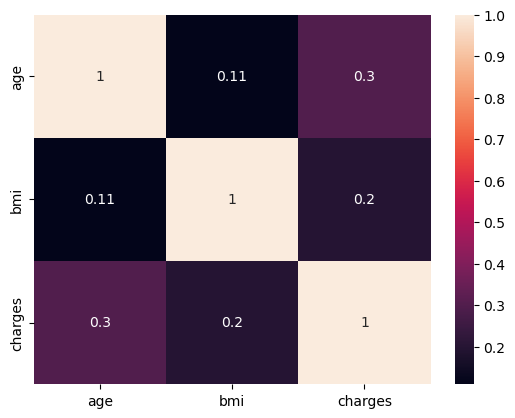

In [87]:
sns.heatmap(df[continous].corr(), annot = True)

**Observation**
- **if the correlation betn any 2 independent variables is >= 0.5 then it is called as colinearity problem**
- **sloution**: drop 1 of them
- in this colinearity problem occur
- input to input colinearity should be low
- but in this example colinearity is (bmi & age) is high(0.11) so i need to drop one of them but first check vif.

# VIF (Various inflation factor)

In [88]:
import statsmodels.formula.api as smf

rsq_age = smf.ols('age~bmi', data = df).fit().rsquared
vif_age = 1/(1-rsq_age)
vif_age


rsq_bmi = smf.ols('bmi~age', data = df).fit().rsquared
vif_bmi = 1/(1-rsq_bmi)
vif_bmi




# storing vif_values in dataframe
d1 = {'variables' : ['age', 'bmi'], 'VIF' : [vif_age, vif_bmi]}
vif_frame = pd.DataFrame(d1)
vif_frame

,variables,VIF
0,age,1.012101
1,bmi,1.012101


**if vif value is  >=4 we have to drop that column**
- but here is no need to drop any column

# Preprocessing 

In [89]:
# no need to do data cleaning
# no need to do data wrangling

# correlation Observations with Target Variable (Charges):

Strong Positive Correlation:

- smoker: 0.79 — The smoking status has a strong positive correlation with the target variable (charges). Smokers tend to have higher charges than non-smokers.
Moderate Positive Correlation:

- age: 0.30 — Older individuals are somewhat positively correlated with higher charges.
- bmi: 0.20 — A moderate positive correlation between BMI and charges, suggesting that higher BMI could be linked to higher charges.
Weak Positive Correlation:

- region_southeast: 0.08 — There is a weak positive correlation between the region being southeast and charges.
- children: 0.07 — The number of children has a weak positive correlation with charges.
- gender: 0.06 — Gender has a very weak positive correlation with charges.
Negligible or Weak Negative Correlation:

- region_northwest: -0.04 — A very weak negative correlation between the northwest region and charges.
- region_southwest: -0.05 — A very weak negative correlation between the southwest region and charges.

Key Insights:

- smoker is the strongest predictor for charges in this dataset, with a clear distinction between smokers and non-smokers.
- age and bmi also have some moderate positive correlations with charges, indicating that older individuals and those with higher BMI may incur higher charges.
- The region variables and children have weak or negligible correlations with charges.


In [90]:
X = df[['age', 'gender', 'bmi', 'children', 'smoker']]
y = df['charges']

In [91]:
# checking for random state no.

Train = []

CV = []

for i in range(0,10):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = i)
    
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    ypred_train = model.predict(X_train)
    
    from sklearn.metrics import r2_score
    Train.append(r2_score(y_train, ypred_train))
    
    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(model, X_train, y_train, cv = 5).mean())
    
em = pd.DataFrame({"Train" : Train, "CV" : CV})
gm = em[(abs(em["Train"] - em["CV"]) <= 0.05)]
rs = gm[gm["CV"] == gm["CV"].max()].index.tolist()[0]
print("Best Random state number is : ", rs)

Best Random state number is :  9


In [92]:
df.duplicated().sum()

0

In [93]:
df.to_csv('cleaned_dataset_medical_cost_insurance.csv', index=False)

In [94]:
pwd

'E:\\Data Science by SRK\\Machine_learning\\project\\Medical Insurance Costs Dataset'